<a href="https://colab.research.google.com/github/Optimus0205/Computer-Vision/blob/main/7_Building_Model_Architecture_for_LeNet_%26_Alexnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Creating Directory

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_851dfe675ddff41bb9613a44badd64be"

In [ ]:
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
!kaggle datasets download -d salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:08<00:00, 135MB/s]



In [ ]:
!unzip /content/dogsvscats.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/dogs/dog.4419.jpg  
  inflating: /content/train/dogs/dog.442.jpg  
  inflating: /content/train/dogs/dog.4420.jpg  
  inflating: /content/train/dogs/dog.4421.jpg  
  inflating: /content/train/dogs/dog.4422.jpg  
  inflating: /content/train/dogs/dog.4424.jpg  
  inflating: /content/train/dogs/dog.4425.jpg  
  inflating: /content/train/dogs/dog.4426.jpg  
  inflating: /content/train/dogs/dog.4427.jpg  
  inflating: /content/train/dogs/dog.4431.jpg  
  inflating: /content/train/dogs/dog.4433.jpg  
  inflating: /content/train/dogs/dog.4436.jpg  
  inflating: /content/train/dogs/dog.4438.jpg  
  inflating: /content/train/dogs/dog.4439.jpg  
  inflating: /content/train/dogs/dog.444.jpg  
  inflating: /content/train/dogs/dog.4440.jpg  
  inflating: /content/train/dogs/dog.4441.jpg  
  inflating: /content/train/dogs/dog.4442.jpg  
  inflating: /content/train/dogs/dog.4443.jpg  
  inflating: /content/train/dogs/dog.44

##Installing all the libraries

In [ ]:
!pip3 install tensorflow numpy matplotlib lib keras

Importing Libraries

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

import tensorflow as tf
from tensorflow.keras import layers,models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img
from keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

## Setting up path

In [ ]:
cat_directory_path='/content/catsvsdogs/train/cats'
dog_directory_path='/content/catsvsdogs/train/dogs'

In [ ]:
# Set path to dataset
data_dir='/content/catsvsdogs/train'

# Hyperparameters
img_width,img_height= 224,224  # Alexnet input size
batch_size=32
epochs=5
validation_split=0.2

In [ ]:
# Load Datasets
train_dataset=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=validation_split,
    subset='training',
    seed=123,
    image_size=(img_width,img_height),
    batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Using 16000 files for training.


In [ ]:
validation_dataset=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=validation_split,
    subset='validation',
    seed=123,
    image_size=(img_width,img_height),
    batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Using 4000 files for validation.


##Data Augmentation

In [ ]:
# Data Augumentation layer
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [ ]:
# Applying data augmentation only on training dataset
train_dataset=train_dataset.map(lambda x,y : (data_augmentation(x,training=True),y))

32 image pass to model training                          
load next batch of 32 imgs and pass to model training

In [ ]:
# Prefetch the datasets for performance
AUTOTUNE=tf.data.AUTOTUNE
train_dataset=train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset=validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Building AlexNet
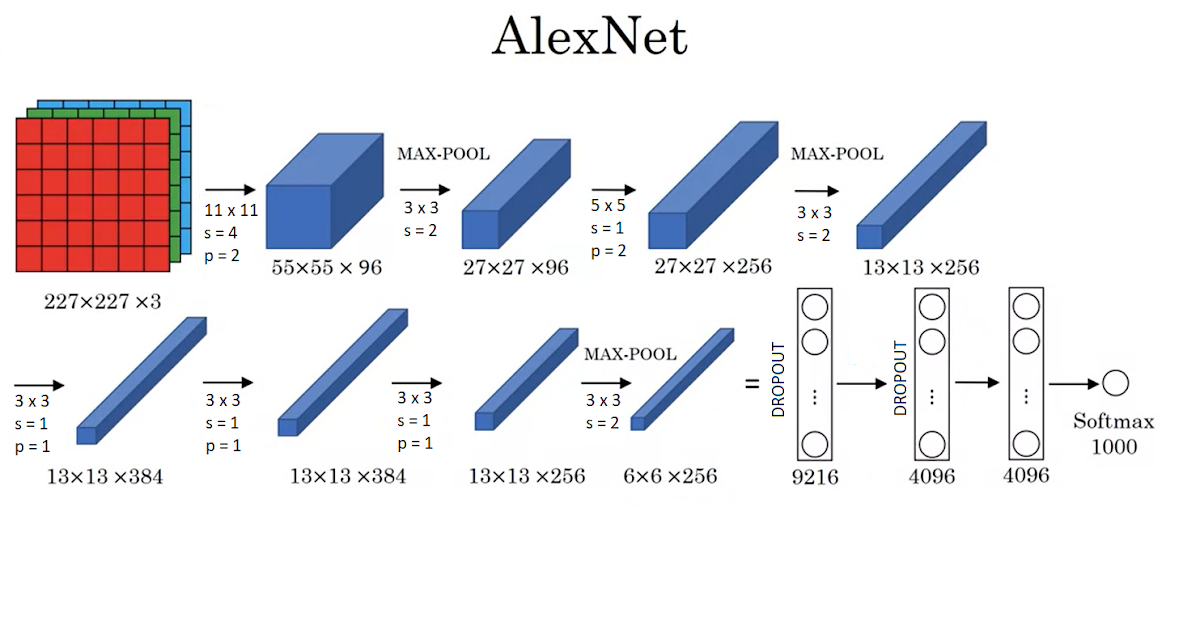

In [ ]:
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,Flatten,Dense,Dropout

#AlexNet Model
alexnet_model=models.Sequential([
    Input(shape=(224,224,3)),

    Conv2D(96,(11,11), strides=(4,4), activation='relu'),
    MaxPooling2D((3,3),strides=(2,2)),

    Conv2D(256,(5,5), padding='same', activation='relu'),
    MaxPooling2D((3,3),strides=(2,2)),

    Conv2D(384,(3,3), padding='same', activation='relu'),
    Conv2D(384,(3,3), padding='same', activation='relu'),
    Conv2D(256,(5,5), padding='same', activation='relu'),

    MaxPooling2D((3,3),strides=(2,2)),

    Flatten(),

    Dense(4096,activation='relu'),
    Dropout(0.5),

    Dense(4096,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

## Model Compile


In [ ]:
alexnet_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [19]:
history=alexnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 201s 402ms/step - accuracy: 0.5007 - loss: 0.6933 - val_accuracy: 0.4915 - val_loss: 0.6936
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 197s 393ms/step - accuracy: 0.4971 - loss: 0.6933 - val_accuracy: 0.4915 - val_loss: 0.6935
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 198s 395ms/step - accuracy: 0.4956 - loss: 0.6933 - val_accuracy: 0.4915 - val_loss: 0.6935
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 196s 393ms/step - accuracy: 0.4971 - loss: 0.6932 - val_accuracy: 0.4915 - val_loss: 0.6936
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 198s 396ms/step - accuracy: 0.5007 - loss: 0.6932 - val_accuracy: 0.4915 - val_loss: 0.6935


In [20]:
#Evaluate the model on validation data
val_loss,val_acuuracy=alexnet_model.evaluate(validation_dataset)
print(f'Validation Acuuracy : {val_acuuracy*100:.2f}%')

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4915 - loss: 0.6935
Validation Acuuracy : 49.15%


In [21]:
alexnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │     2,457,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,971,909 (553.02 MB)

 Trainable params: 48,323,969 (184.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 96,647,940 (368.68 MB)

In [22]:
alexnet_model.save('saved_model_5_epochs.keras')

In [35]:
alexnet_model.save_weights('model_5.weights.h5')

## Loading the saved model of epochs

In [23]:
from tensorflow.keras.models import load_model

# Load the model
loaded_model=load_model('saved_model_5_epochs.keras')

# Now we can use the load model for inference or further testing

In [26]:
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │     2,457,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,971,909 (553.02 MB)

 Trainable params: 48,323,969 (184.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 96,647,940 (368.68 MB)

In [27]:
history=loaded_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=2
)

Epoch 1/2
500/500 ━━━━━━━━━━━━━━━━━━━━ 208s 406ms/step - accuracy: 0.4992 - loss: 0.6933 - val_accuracy: 0.4915 - val_loss: 0.6934
Epoch 2/2
500/500 ━━━━━━━━━━━━━━━━━━━━ 226s 453ms/step - accuracy: 0.4956 - loss: 0.6932 - val_accuracy: 0.4915 - val_loss: 0.6934


In [28]:
history_dict=history.history
history_dict

{'accuracy': [0.49924999475479126, 0.49562498927116394],
 'loss': [0.6932913661003113, 0.6932259798049927],
 'val_accuracy': [0.49149999022483826, 0.49149999022483826],
 'val_loss': [0.6934290528297424, 0.6934143304824829]}

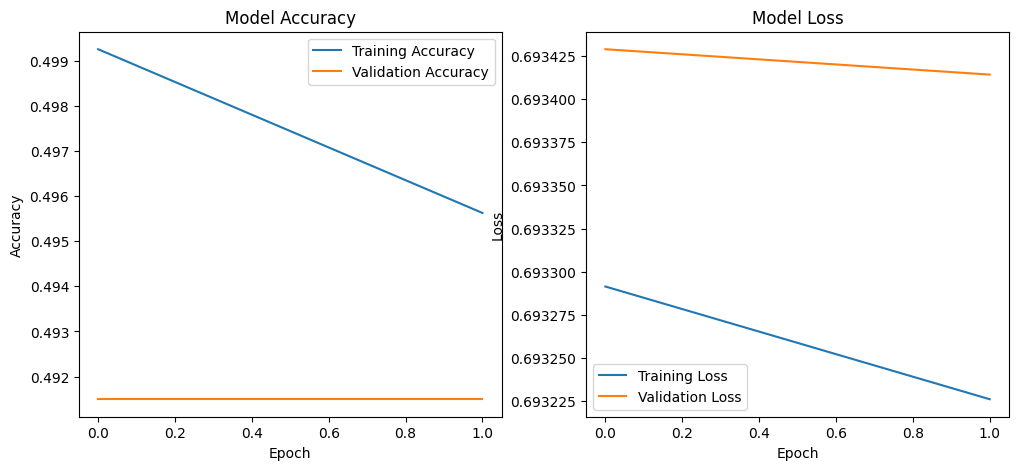

In [29]:
import matplotlib.pyplot as plt

#Assuming you have a history object returned from model.fit()
history_dict=history.history # Access the history dataset

#Plotting accuracy
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Building LeNet
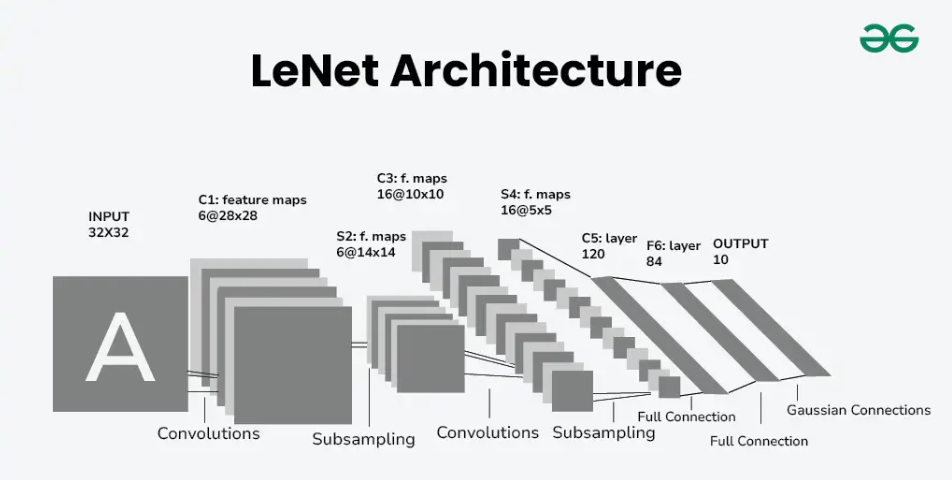

In [34]:
lenet_model=models.Sequential([
    Conv2D(32, (5,5), activation='tanh', input_shape=(32,32,1)),
    MaxPooling2D((2,2)),

    Conv2D(64,(5,5), activation='tanh'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='tanh'),
    Dense(1, activation='sigmoid')
])